# This model is trained on (2020/01/01  to  2023/12/30) 48 month data with STATIC MASK

## Masked on CMEMS depth data

In [ ]:
# ==============================================================================
# MASTER CONFIGURATION CELL
# ==============================================================================
import torch
import os

LOOKBACK_HOURS = 48
FORECAST_HORIZON_HOURS = 168
PREDICTION_WINDOW = 3 # Predict 3 hours at once

# --- File Paths ---

# MODIFICATION: Updated to the new file paths you provided
RAW_DATA_PATH = r'/home/aidl/Wave-Prediction/V2/new_dAtA/till xl.nc'                     #['VHM0_SW1','VHM0_WW']
RAW_DATA_PATH1 = r'/home/aidl/Wave-Prediction/V2/new_dAtA/after_xl.nc'                   #['VTM01_WW','VTM02','VTM01_SW1','VTM10','VSDX','VSDY','VSDmag']
STATIC_DATA_PATH = r'/home/aidl/Wave-Prediction/V2/new_dAtA/cmems_GEBCO_resampled_new.nc'

# MODIFICATION: File paths are now dynamic to keep experiments separate
BASE_DIR = r'D:\babe_prediction'
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, f'processed_data_lookback_{LOOKBACK_HOURS}_static_old')
MODEL_SAVE_PATH = f'models/convlstm_lookback_{LOOKBACK_HOURS}_forecast_{FORECAST_HORIZON_HOURS}_static_old.pth'

# --- Feature Engineering ---
# These are the TIME-VARYING features
VARS_TO_USE = ['VHM0_SW1', 'VSDmag', 'VHM0_WW', 'VTM01_WW', 'VTM02', 'VTM01_SW1', 'VTM10']
TARGET_VARS = VARS_TO_USE # Based on your TARGET_FEATURES list
NUM_TARGETS = len(TARGET_VARS)

# MODIFICATION: Total input channels = 9 time-varying + 2 static (depth, mask)
INPUT_CHANNELS = len(TARGET_VARS) + 2

# --- Training Hyperparameters ---
LEARNING_RATE = 1e-5
BATCH_SIZE = 4
EPOCHS = 50
# MODIFICATION: Early stopping patience is now a configurable parameter
EARLY_STOPPING_PATIENCE = 5

# --- System Configuration ---
NUM_WORKERS = 0  # Set to 0 if you encounter multiprocessing issues, 4+ for speed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Print a summary of the current configuration ---
print("--- Configuration Summary ---")
print(f"Input Channels: {INPUT_CHANNELS} ({len(VARS_TO_USE)} time + 2 static)")
print(f"Lookback Period: {LOOKBACK_HOURS} hours")
print(f"Forecast Horizon: {FORECAST_HORIZON_HOURS} hours")
print(f"Processed Data Path: {PROCESSED_DATA_DIR}")
print(f"Model Save Path: {MODEL_SAVE_PATH}")
print(f"Using Device: {device}")
print("---------------------------")

--- Configuration Summary ---
Lookback Period: 48 hours
Forecast Horizon: 168 hours
Input Channels: 11 (9 time-varying + 2 static)
Processed Data Path: D:\babe_prediction\processed_data_lookback_48_static_old
Model Save Path: convlstm_lookback_48_forecast_168_static_old.pth
Using Device: cuda
---------------------------


# STEP 1: PRE-PROCESSING SCRIPT (with Static Features)

In [ ]:
# ==============================================================================
# Step 1: Load and Merge Data
# ==============================================================================
print("\n[Step 1/5] Loading and merging raw data files...")

try:
    ds1 = xr.open_dataset(RAW_DATA_PATH)
    ds2 = xr.open_dataset(RAW_DATA_PATH1)
    # Merge the two datasets on the time dimension
    ds_raw = xr.merge([ds1, ds2])
except FileNotFoundError as e:
    raise SystemExit(f"❌ ERROR: Raw data file not found: {e}")

# Calculate magnitudes if not already present
if 'VSDmag' not in ds_raw:
    ds_raw['VSDmag'] = np.sqrt(ds_raw['VSDX']**2 + ds_raw['VSDY']**2)
    
# Assuming strokes_drift_mag is the same as VSDmag or calculated from VSD components
if 'strokes_drift_mag' not in ds_raw:
    ds_raw['strokes_drift_mag'] = ds_raw['VSDmag']

# Create a master list of all variables needed (inputs + targets)
all_needed_vars = list(set(VARS_TO_USE + TARGET_VARS))
ds_clean = ds_raw[all_needed_vars].astype(np.float32).fillna(0)
print("✅ Time-varying data merged and cleaned.")

try:
    ds_static = xr.open_dataset(STATIC_DATA_PATH)
    ocean_depth = np.nan_to_num(ds_static['deptho'].values, nan=0.0).astype(np.float32)
    ocean_mask = ds_static['mask'].values.astype(np.float32)
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Static data file not found at {STATIC_DATA_PATH}.")
print("✅ Static data loaded.")

# ==============================================================================
# Step 2: Define Data Splits
# ==============================================================================
print("\n[Step 2/5] Splitting data into sets...")
ds_train = ds_clean.sel(time=slice('2020-01-01', '2022-12-31'))
ds_val = ds_clean.sel(time=slice('2023-01-01', '2023-06-30'))
ds_test = ds_clean.sel(time=slice('2023-07-01', '2023-12-30'))
ds_splits = {'train': ds_train, 'val': ds_val, 'test': ds_test}

# ==============================================================================
# Step 3: Create and Save Scalers
# ==============================================================================
print("\n[Step 3/5] Fitting scalers...")
scalers = {}
for var in tqdm(all_needed_vars, desc="Fitting Scalers"):
    data_to_fit = ds_train[var].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    scaler.fit(data_to_fit)
    scalers[var] = scaler

depth_scaler = MinMaxScaler()
depth_scaler.fit(ocean_depth.reshape(-1, 1))
scalers['ocean_depth'] = depth_scaler

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
with open(os.path.join(PROCESSED_DATA_DIR, 'scalers.pkl'), 'wb') as f:
    pickle.dump(scalers, f)

# ==============================================================================
# Step 4: Scale Static Features
# ==============================================================================
scaled_depth = scalers['ocean_depth'].transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
static_features_np = np.stack([scaled_depth, ocean_mask], axis=0) # [2, H, W]

# ==============================================================================
# Step 5: Process and Save Samples
# ==============================================================================
print("\n[Step 5/5] Generating samples...")
total_window_size = LOOKBACK_HOURS + FORECAST_HORIZON_HOURS

# Get indices for targeting in the output tensor
target_indices = [all_needed_vars.index(v) for v in TARGET_VARS]
input_indices = [all_needed_vars.index(v) for v in VARS_TO_USE]

for split_name, ds_split in ds_splits.items():
    split_dir = os.path.join(PROCESSED_DATA_DIR, split_name)
    os.makedirs(split_dir, exist_ok=True)
    
    num_sequences = len(ds_split['time']) - total_window_size
    for i in tqdm(range(num_sequences), desc=f"Saving {split_name} samples"):
        window_data = ds_split.isel(time=slice(i, i + total_window_size))
        
        # Scale all variables in the window
        scaled_vars = []
        for var in all_needed_vars:
            raw_vals = window_data[var].values
            scaled_vals = scalers[var].transform(raw_vals.reshape(-1, 1)).reshape(raw_vals.shape)
            scaled_vars.append(scaled_vals)
        
        # [Total_Window, Total_Vars, H, W]
        full_tensor = np.stack(scaled_vars, axis=1)

        # X: Lookback period with only input variables
        X_tv = full_tensor[:LOOKBACK_HOURS, input_indices, :, :]
        
        # y: Forecast period with only target variables
        y_raw = full_tensor[LOOKBACK_HOURS:, target_indices, :, :]
        # Reshape y to [Time * Channels, H, W] for Conv2D output layer compatibility
        y_final = y_raw.reshape(-1, y_raw.shape[-2], y_raw.shape[-1])

        # Tile static features across time dimension for X
        static_tiled = np.tile(static_features_np, (LOOKBACK_HOURS, 1, 1, 1))
        X_final = np.concatenate([X_tv, static_tiled], axis=1) # [48, 11, H, W]

        sample_path = os.path.join(split_dir, f'sample_{i:06d}.pt')
        torch.save((torch.from_numpy(X_final), torch.from_numpy(y_final)), sample_path)

print("\n✅ Pre-processing complete!")


--- Starting Full Pre-processing Workflow ---

[Step 1/5] Loading and cleaning all data...
✅ Time-varying data loaded and cleaned.
✅ Static data loaded and cleaned.

[Step 2/5] Splitting data into train, validation, and test sets...
Train split: 26304 time steps
Validation split: 4344 time steps
Test split: 4392 time steps

[Step 3/5] Fitting scalers on TRAINING data only...


Fitting Time-Varying Scalers:   0%|          | 0/9 [00:00<?, ?it/s]

Fitting static feature scalers...
✅ All scalers fitted and saved to 'D:\babe_prediction\processed_data_lookback_48_static_old\scalers.pkl'

[Step 4/5] Scaling static features...
✅ Static features scaled.

[Step 5/5] Generating and saving individual samples...

--- Processing 'train' split ---


Saving train samples:   0%|          | 0/26088 [00:00<?, ?it/s]


--- Processing 'val' split ---


Saving val samples:   0%|          | 0/4128 [00:00<?, ?it/s]


--- Processing 'test' split ---


Saving test samples:   0%|          | 0/4176 [00:00<?, ?it/s]



✅ Pre-processing complete with static features!
Clean, processed data is now available at: 'D:\babe_prediction\processed_data_lookback_48_static_old'


# STEP 2: TRAINING SCRIPT

In [ ]:
# ==============================================================================
# ==============================================================================
import os
import pickle
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import time
import numpy as np

class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir, target_indices=None): # Added default None
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
        self.target_indices = target_indices

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Your preprocessing saves X and y as a tuple (X_final, y_final)
        # We must unpack them correctly
        x, y = torch.load(self.file_paths[idx])
        
        # Crop y if training on a smaller window than the full 168h forecast
        # y shape from preprocessing is [Time * Channels, H, W]
        # For a 3h prediction window: 3 * 7 = 21 channels
        y_slice = y[:(PREDICTION_WINDOW * NUM_TARGETS), :, :]
        
        return x, y_slice

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvLSTMCell, self).__init__(); self.input_dim, self.hidden_dim, self.kernel_size, self.bias = input_dim, hidden_dim, kernel_size, bias; self.padding = kernel_size[0] // 2; self.conv = nn.Conv2d(self.input_dim + self.hidden_dim, 4 * self.hidden_dim, self.kernel_size, padding=self.padding, bias=self.bias)
    def forward(self, x, h_c): h, c = h_c; combined = torch.cat([x, h], dim=1); cc = self.conv(combined); i, f, o, g = torch.split(cc, self.hidden_dim, dim=1); i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g); c_n = f * c + i * g; h_n = o * torch.tanh(c_n); return h_n, c_n
    def init_hidden(self, b, i, d): h, w = i; return (torch.zeros(b, self.hidden_dim, h, w, device=d), torch.zeros(b, self.hidden_dim, h, w, device=d))

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bias=True):
        super(ConvLSTM, self).__init__(); self.batch_first, self.num_layers = batch_first, num_layers; hidden_dims = [hidden_dim] * num_layers if isinstance(hidden_dim, int) else hidden_dim; cell_list = [];
        for i in range(self.num_layers): cur_input_dim = input_dim if i == 0 else hidden_dims[i - 1]; cell_list.append(ConvLSTMCell(cur_input_dim, hidden_dims[i], kernel_size, bias)); self.cell_list = nn.ModuleList(cell_list)
    def forward(self, x, h_c=None):
        b, s_l, _, h, w = x.size();
        if h_c is None: h_c = self._init_hidden(b, (h, w), x.device)
        cur_in = x
        for l_idx in range(self.num_layers):
            h, c = h_c[l_idx]; output_inner = []
            for t in range(s_l): h, c = self.cell_list[l_idx](cur_in[:, t, :, :, :], [h, c]); output_inner.append(h)
            cur_in = torch.stack(output_inner, dim=1)
        return cur_in, [h, c]
    def _init_hidden(self, b, i, d): return [cell.init_hidden(b, i, d) for cell in self.cell_list]

# --- ConvLSTMNet Class Fix ---
class ConvLSTMNet(nn.Module):
    def __init__(self, input_dim, num_targets, prediction_window, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvLSTMNet, self).__init__()
        self.cl1 = ConvLSTM(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True)
        self.cl2 = ConvLSTM(hidden_dims[0], hidden_dims[1], kernel_size, 1, batch_first=True)
        
        # Output: 7 features * 3 hours = 21 channels
        self.output_conv = nn.Conv2d(
            hidden_dims[1], 
            num_targets * prediction_window, 
            kernel_size=(1, 1)
        )

    def forward(self, x_seq):
        l1_o, _ = self.cl1(x_seq)
        l2_o, _ = self.cl2(l1_o)
        out = self.output_conv(l2_o[:, -1, :, :, :]) 
        return out

def train_model(model, train_loader, val_loader, device, epochs, lr, patience, model_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr); loss_fn = nn.MSELoss(); best_val_loss = float('inf'); scaler = torch.cuda.amp.GradScaler(); epochs_no_improve = 0
    print("\n--- Starting Model Training ---")
    for epoch in range(epochs):
        start_time = time.time(); model.train(); total_train_loss = 0.0; train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]")
        for X, y in train_pbar:
            X, y = X.to(device), y.to(device); optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(): predicted = model(X); target = y; loss = loss_fn(predicted, target)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update(); total_train_loss += loss.item(); train_pbar.set_postfix({'loss': f'{loss.item():.6f}'})
        avg_train_loss = total_train_loss / len(train_loader); model.eval(); total_val_loss = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                with torch.cuda.amp.autocast(): predicted = model(X); target = y; loss = loss_fn(predicted, target)
                total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_loader); epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} - {epoch_time:.1f}s - Train Loss: {avg_train_loss:.6f} - Val Loss: {avg_val_loss:.6f}")
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss; epochs_no_improve = 0; torch.save(model.state_dict(), model_path); print(f"✅ New best model saved with validation loss: {best_val_loss:.6f}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience: print(f"Early stopping triggered after {epoch+1} epochs."); break
    print(f"\n✅ Training completed. Best model saved to {model_path}"); model.load_state_dict(torch.load(model_path)); return model

In [ ]:
# --- Main Execution Logic ---
if __name__ == '__main__':
    train_dir = os.path.join(PROCESSED_DATA_DIR, 'train')
    val_dir = os.path.join(PROCESSED_DATA_DIR, 'val')
    train_dataset = PreprocessedWaveDataset(train_dir)
    val_dataset = PreprocessedWaveDataset(val_dir)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True if NUM_WORKERS > 0 else False)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True if NUM_WORKERS > 0 else False)
    print(f"\nDataLoaders created with {len(train_dataset)} training samples and {len(val_dataset)} validation samples.")
    
    model = ConvLSTMNet(
        input_dim=INPUT_CHANNELS, 
        num_targets=NUM_TARGETS, 
        prediction_window=PREDICTION_WINDOW
    )
    model.to(device)
    print(f"Model built with {INPUT_CHANNELS} input channels and a {FORECAST_HORIZON_HOURS}-hour forecast horizon.")

    trained_model = train_model(
        model=model, train_loader=train_loader, val_loader=val_loader, device=device,
        epochs=EPOCHS, lr=LEARNING_RATE, patience=EARLY_STOPPING_PATIENCE, model_path=MODEL_SAVE_PATH
    )


DataLoaders created with 26088 training samples and 4128 validation samples.
Model built with 11 input channels and a 168-hour forecast horizon.

--- Starting Model Training ---


Epoch 1/50 [Training]:   0%|          | 0/6522 [00:00<?, ?it/s]

Epoch 1/50 - 12603.9s - Train Loss: 0.016903 - Val Loss: 0.008303
✅ New best model saved with validation loss: 0.008303


Epoch 2/50 [Training]:   0%|          | 0/6522 [00:00<?, ?it/s]

Epoch 2/50 - 12454.4s - Train Loss: 0.008072 - Val Loss: 0.007252
✅ New best model saved with validation loss: 0.007252


...

Epoch 12/50 - 12501.8s - Train Loss: 0.006840 - Val Loss: 0.006801


Epoch 13/50 [Training]:   0%|          | 0/6522 [00:00<?, ?it/s]

Epoch 13/50 - 12451.5s - Train Loss: 0.006798 - Val Loss: 0.006746


Epoch 14/50 [Training]:   0%|          | 0/6522 [00:00<?, ?it/s]

Epoch 14/50 - 12425.7s - Train Loss: 0.006770 - Val Loss: 0.006594
Early stopping triggered after 14 epochs.

✅ Training completed. Best model saved to convlstm_lookback_48_forecast_168_static_old.pth


# STEP 3: EVALUATION AND VISUALIZATION SCRIPT

In [ ]:
def predict_30_hours(model, initial_input, static_features, device):
    """
    initial_input: [1, 48, 11, H, W]
    static_features: [1, 4, H, W] (The channels not predicted by the model)
    """
    model.eval()
    current_window = initial_input.to(device)
    all_predictions = []

    with torch.no_grad():
        for _ in range(10): # 10 iterations * 3 hours = 30 hours
            # Predict next 3 hours: [1, 21, H, W]
            pred = model(current_window) 
            
            # Reshape back to [1, 3, 7, H, W]
            pred_reshaped = pred.view(1, 3, 7, pred.shape[-2], pred.shape[-1])
            all_predictions.append(pred_reshaped)

            # To slide the window, we need 11 channels. 
            # We combine the 7 predicted channels with the 4 static channels.
            for t in range(3):
                single_hour_pred = pred_reshaped[:, t, :, :, :] # [1, 7, H, W]
                full_hour_step = torch.cat([single_hour_pred, static_features], dim=1) # [1, 11, H, W]
                
                # Slide: Remove oldest hour, add new hour
                current_window = torch.cat([current_window[:, 1:], full_hour_step.unsqueeze(1)], dim=1)

    return torch.cat(all_predictions, dim=1) # Final [1, 30, 7, H, W]

--- Starting Final Evaluation on the Test Set ---

✅ Best model loaded successfully.

--- Generating predictions and calculating hourly errors... ---



Evaluating Test Set:   0%|          | 0/1044 [00:00<?, ?it/s]


📊 Overall Test Results (all 168 hours):
  Overall RMSE: 1.5660
  Overall MAE:  0.9653

--- Generating Visualization: Spatially-Averaged Time Series ---


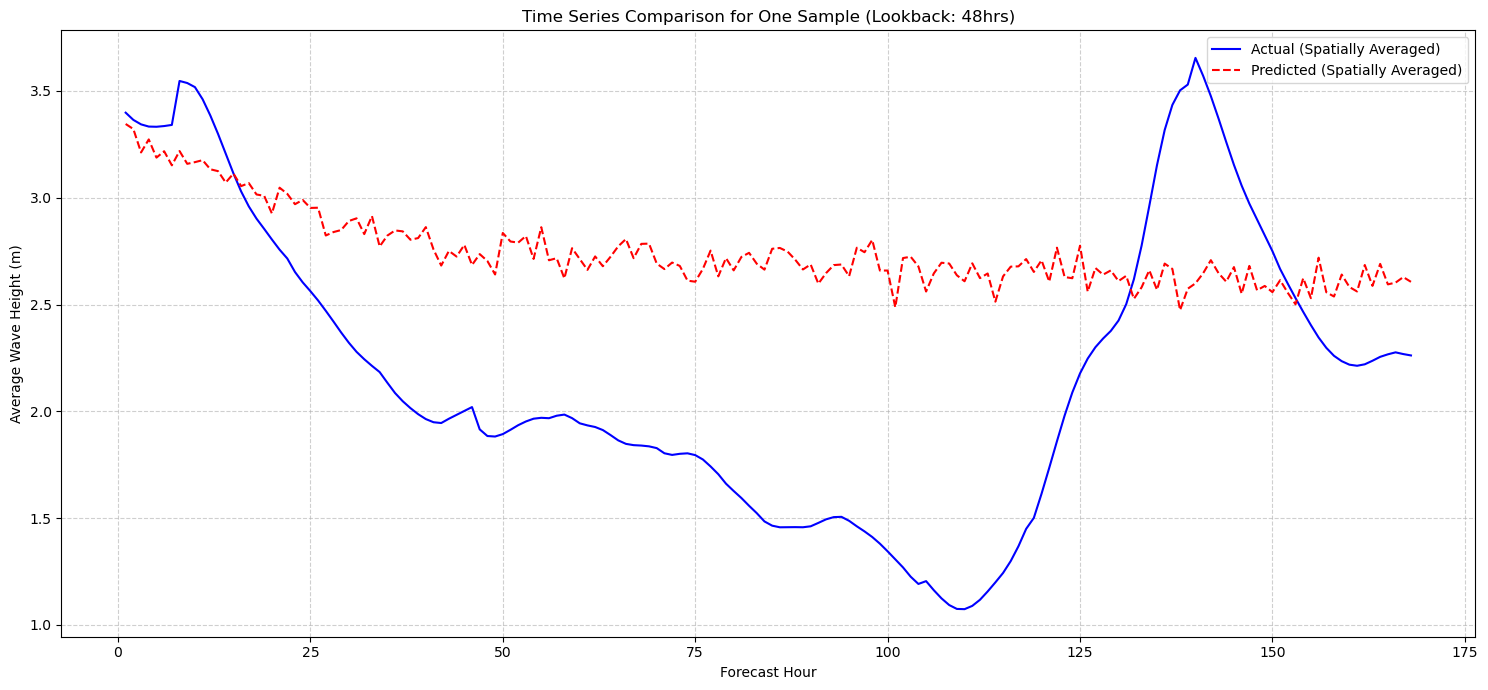


--- Generating Visualization: Average Error per Forecast Hour ---


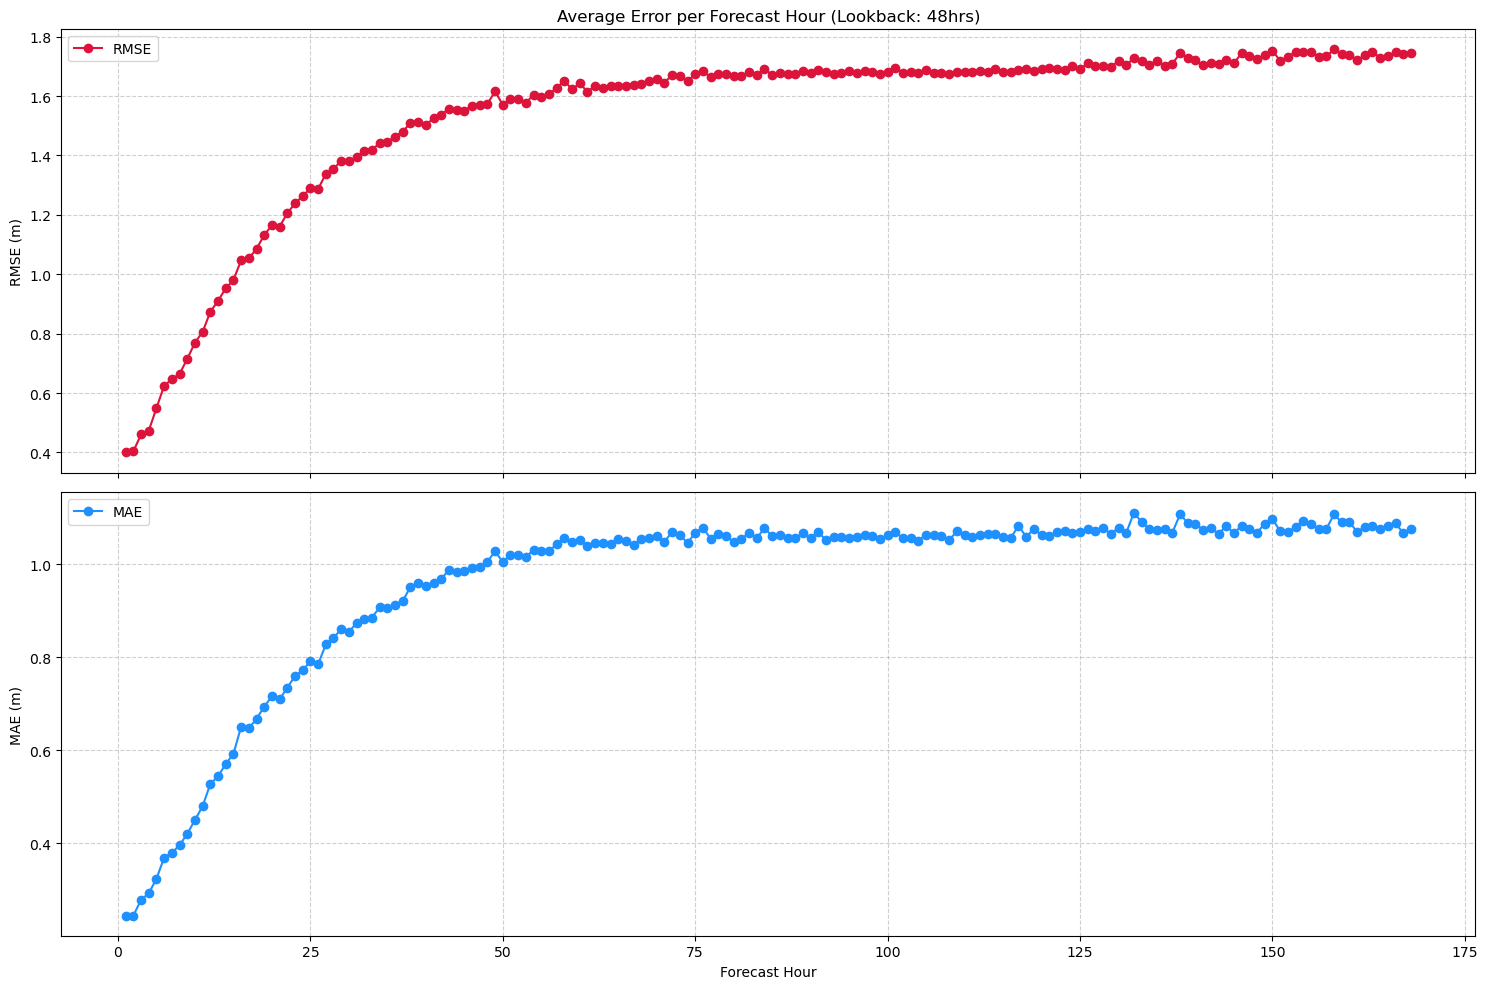


--- Generating Visualization 1: Comparison Maps ---


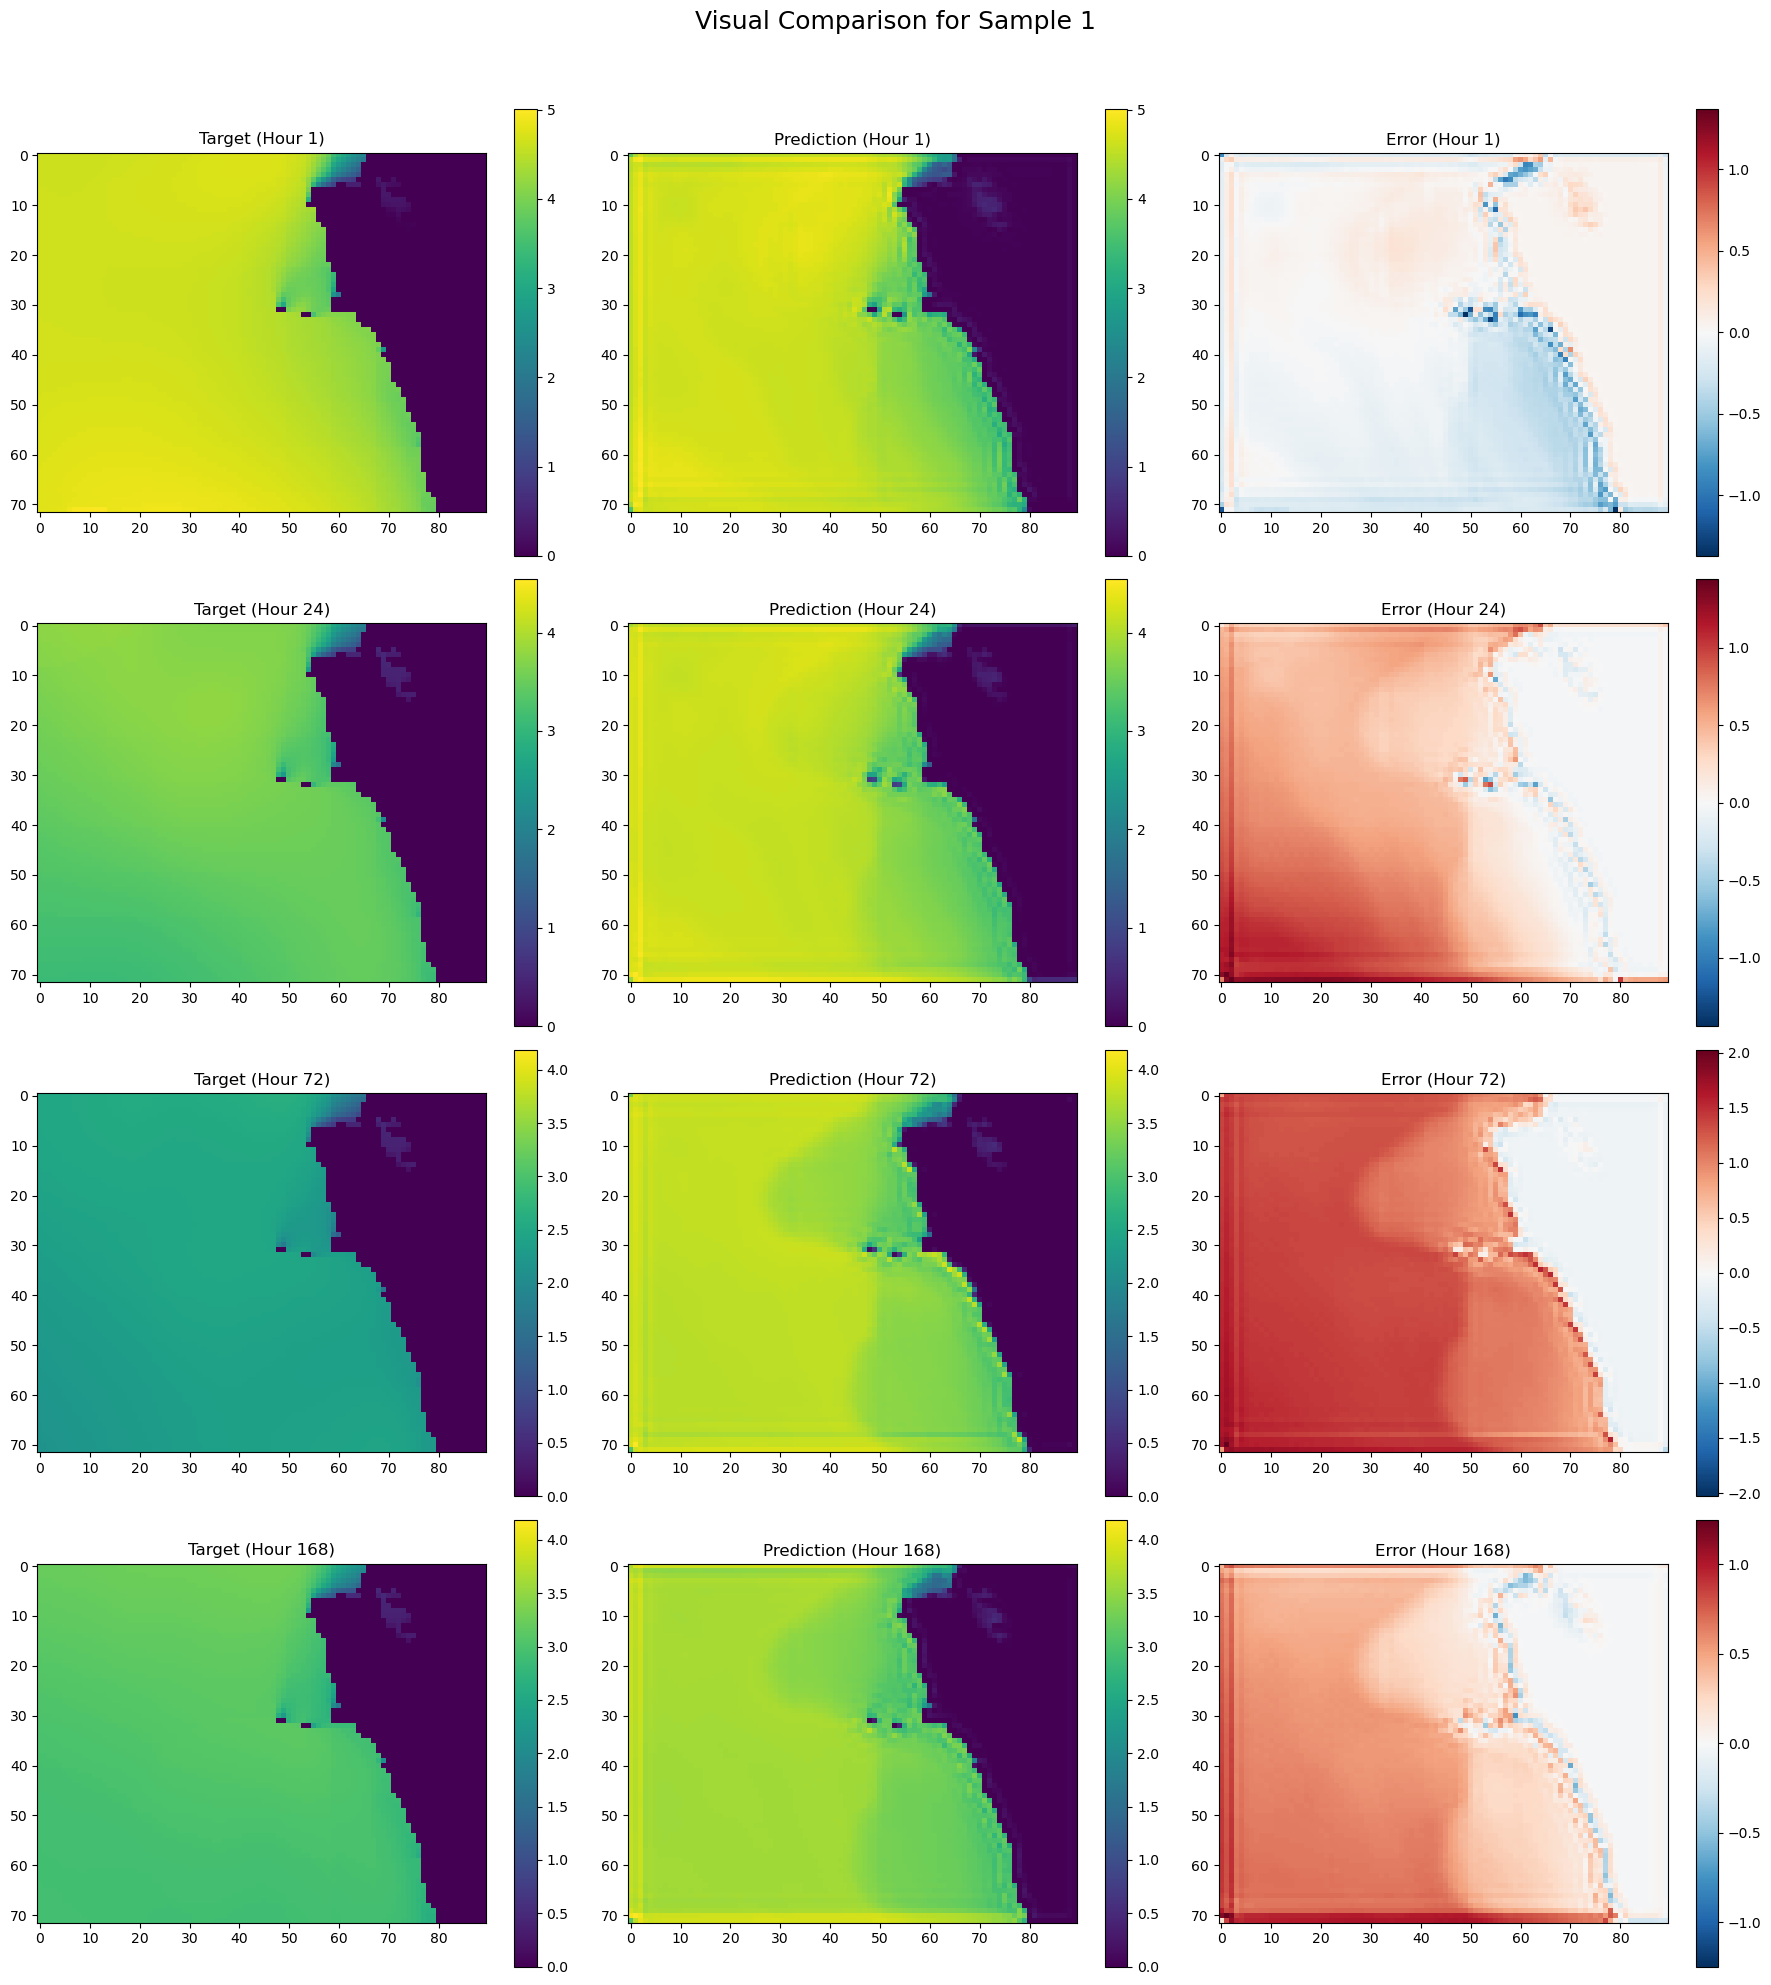

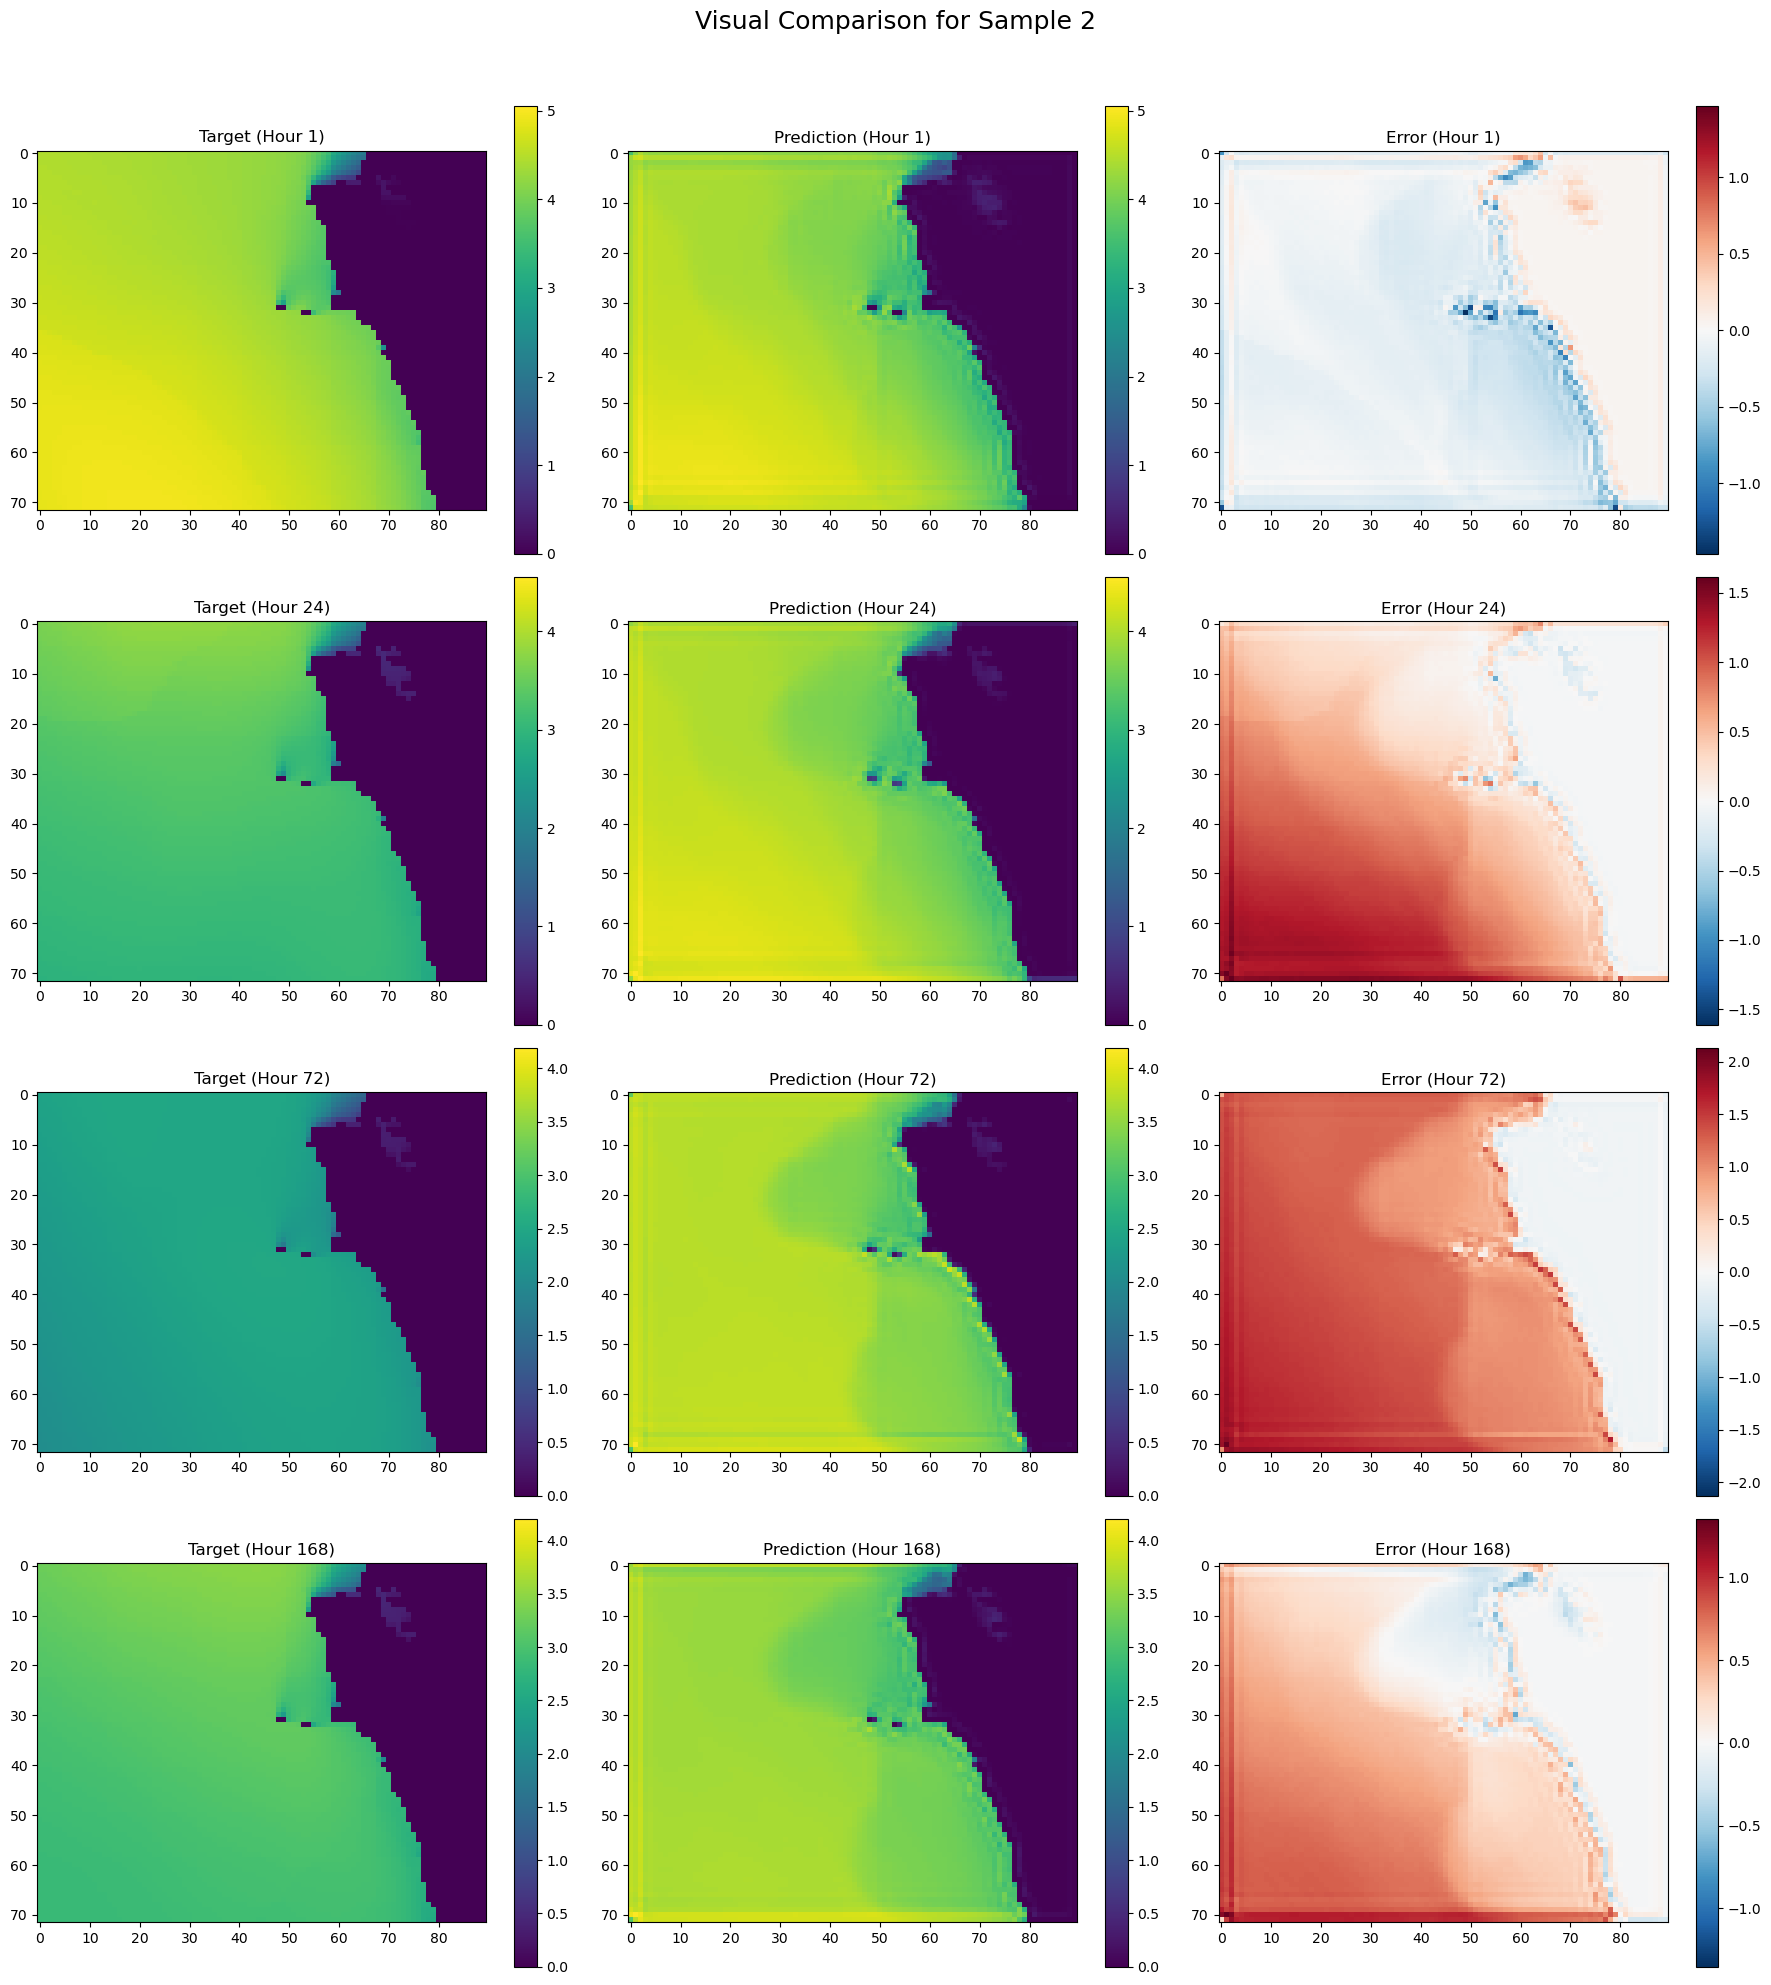

✅ Comparison maps saved to 'test_comparison_lookback_48_X.png'

--- Generating Visualization 2 & 3: Scatter and Error Plots ---


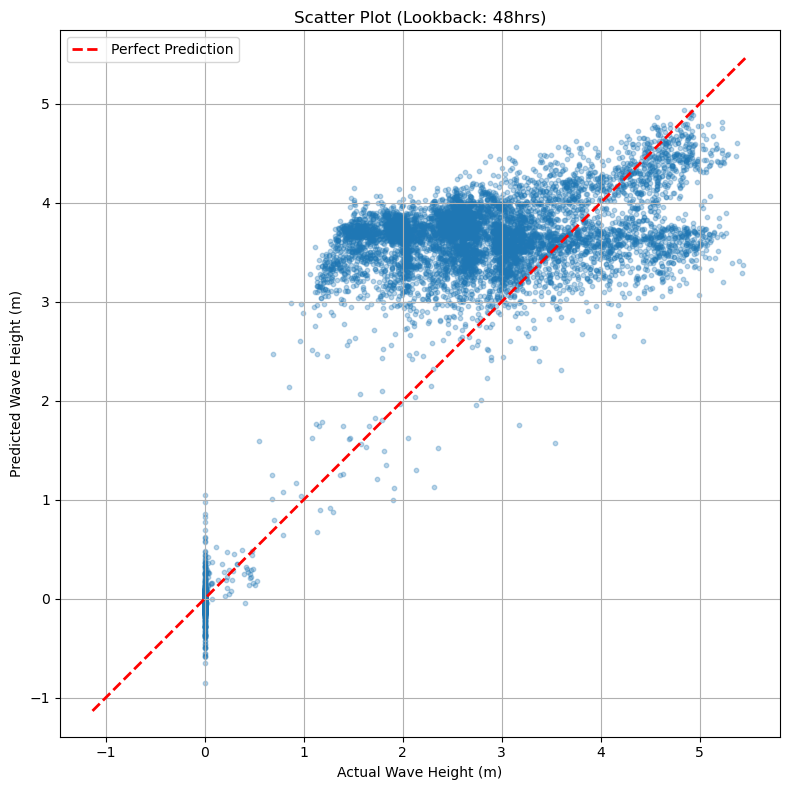

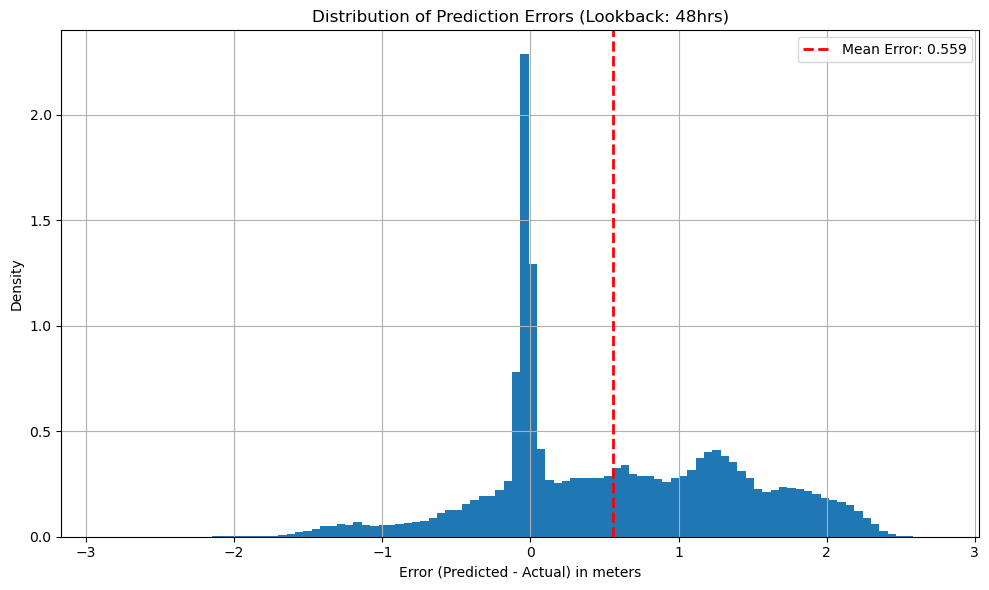


✅ All evaluation visualizations are complete.


In [9]:
# ==============================================================================
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
import pickle
import glob
from torch.utils.data import Dataset, DataLoader

print("--- Starting Final Evaluation on the Test Set ---\n")

# --- Define Classes ---
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

class ConvLSTMCell(nn.Module):
    def __init__(self, i, h, k, b): super(ConvLSTMCell, self).__init__(); self.input_dim, self.hidden_dim, self.kernel_size, self.bias = i, h, k, b; self.padding = k[0] // 2; self.conv = nn.Conv2d(i + h, 4 * h, k, padding=self.padding, bias=b)
    def forward(self, x, h_c): h, c = h_c; combined = torch.cat([x, h], dim=1); cc = self.conv(combined); i, f, o, g = torch.split(cc, self.hidden_dim, dim=1); i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g); c_n = f * c + i * g; h_n = o * torch.tanh(c_n); return h_n, c_n
    def init_hidden(self, b, i, d): h, w = i; return (torch.zeros(b, self.hidden_dim, h, w, device=d), torch.zeros(b, self.hidden_dim, h, w, device=d))

class ConvLSTM(nn.Module):
    def __init__(self, i, h, k, n, batch_first=True, bias=True):
        super(ConvLSTM, self).__init__(); self.batch_first, self.num_layers = batch_first, n; h_dims = [h] * n if isinstance(h, int) else h; c_list = [];
        for j in range(self.num_layers): c_i_dim = i if j == 0 else h_dims[j - 1]; c_list.append(ConvLSTMCell(c_i_dim, h_dims[j], k, bias)); self.cell_list = nn.ModuleList(c_list)
    def forward(self, x, h_c=None):
        b, s_l, _, h, w = x.size();
        if h_c is None: h_c = self._init_hidden(b, (h, w), x.device)
        cur_in = x
        for l_idx in range(self.num_layers):
            h, c = h_c[l_idx]; out_inner = []
            for t in range(s_l): h, c = self.cell_list[l_idx](cur_in[:, t, :, :, :], [h, c]); out_inner.append(h)
            cur_in = torch.stack(out_inner, dim=1)
        return cur_in, [h, c]
    def _init_hidden(self, b, i, d): return [cell.init_hidden(b, i, d) for cell in self.cell_list]

class ConvLSTMNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvLSTMNet, self).__init__(); self.cl1 = ConvLSTM(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True); self.cl2 = ConvLSTM(hidden_dims[0], hidden_dims[1], kernel_size, 1, batch_first=True); self.output_conv = nn.Conv2d(hidden_dims[1], forecast_horizon, kernel_size=(1, 1), padding='same')
    def forward(self, x_seq): l1_o, _ = self.cl1(x_seq); l2_o, _ = self.cl2(l1_o); return self.output_conv(l2_o[:, -1, :, :, :])

# --- Load Model and Prepare Test Loader ---
try:
    with open(os.path.join(PROCESSED_DATA_DIR, 'scalers.pkl'), 'rb') as f: scalers = pickle.load(f)
except FileNotFoundError: raise SystemExit(f"❌ ERROR: Scalers file not found for lookback={LOOKBACK_HOURS}.")

test_dir = os.path.join(PROCESSED_DATA_DIR, 'test')
test_dataset = PreprocessedWaveDataset(test_dir)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model = ConvLSTMNet(input_dim=INPUT_CHANNELS, forecast_horizon=FORECAST_HORIZON_HOURS)
try:
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
except FileNotFoundError: raise SystemExit(f"❌ ERROR: Model file '{MODEL_SAVE_PATH}' not found.")

if torch.cuda.device_count() > 1: model = nn.DataParallel(model)
model.to(device)
model.eval()
print("✅ Best model loaded successfully.")

# --- Evaluation and Visualization Functions ---
# --- MODIFIED Evaluation Function and NEW Visualization Functions ---

def evaluate_and_visualize(model, test_loader, device, scalers, target_var, forecast_horizon):
    """
    Evaluates the model and calculates overall metrics PLUS per-hour error metrics.
    """
    model.eval()
    total_samples = 0
    vis_data = {'predictions': [], 'targets': []}

    # Initialize arrays to store error sums for each forecast hour
    hourly_rmse_sum_sq = np.zeros(forecast_horizon)
    hourly_mae_sum = np.zeros(forecast_horizon)
    
    print("\n--- Generating predictions and calculating hourly errors... ---\n")
    with torch.no_grad():
        for i, (X, y) in enumerate(tqdm(test_loader, desc="Evaluating Test Set")):
            X, y = X.to(device), y.to(device)
            predictions_scaled = model(X)
            target_scaled = y
            target_scaler = scalers[target_var]

            pred_original = target_scaler.inverse_transform(predictions_scaled.cpu().numpy().reshape(-1, 1)).reshape(predictions_scaled.shape)
            target_original = target_scaler.inverse_transform(target_scaled.cpu().numpy().reshape(-1, 1)).reshape(target_scaled.shape)

            # Calculate errors for each hour
            sq_error = (pred_original - target_original) ** 2
            abs_error = np.abs(pred_original - target_original)
            
            # Sum errors over batch and spatial dimensions, keeping the time dimension
            hourly_rmse_sum_sq += np.sum(sq_error, axis=(0, 2, 3))
            hourly_mae_sum += np.sum(abs_error, axis=(0, 2, 3))
            
            total_samples += pred_original.size
            if len(vis_data['predictions']) < 2:
                vis_data['predictions'].append(pred_original[0])
                vis_data['targets'].append(target_original[0])

    # Calculate final metrics
    num_spatial_points = pred_original.shape[2] * pred_original.shape[3]
    num_test_examples = len(test_loader.dataset)
    total_samples_per_hour = num_spatial_points * num_test_examples

    overall_rmse = np.sqrt(np.sum(hourly_rmse_sum_sq) / total_samples)
    overall_mae = np.sum(hourly_mae_sum) / total_samples
    
    hourly_rmse = np.sqrt(hourly_rmse_sum_sq / total_samples_per_hour)
    hourly_mae = hourly_mae_sum / total_samples_per_hour
    
    print(f"\n📊 Overall Test Results (all {forecast_horizon} hours):")
    print(f"  Overall RMSE: {overall_rmse:.4f}")
    print(f"  Overall MAE:  {overall_mae:.4f}")

    return vis_data, hourly_rmse, hourly_mae

def plot_timeseries_comparison(vis_data, forecast_horizon):
    """
    Plots a time-series comparison of the spatially-averaged wave height for a single sample.
    """
    print("\n--- Generating Visualization: Spatially-Averaged Time Series ---")
    
    prediction_sample = vis_data['predictions'][0]
    target_sample = vis_data['targets'][0]

    # Calculate the mean value over the spatial grid for each time step
    pred_mean_over_time = np.mean(prediction_sample, axis=(1, 2))
    target_mean_over_time = np.mean(target_sample, axis=(1, 2))
    
    hours = np.arange(1, forecast_horizon + 1)
    
    plt.figure(figsize=(15, 7))
    plt.plot(hours, target_mean_over_time, 'b-', label='Actual (Spatially Averaged)')
    plt.plot(hours, pred_mean_over_time, 'r--', label='Predicted (Spatially Averaged)')
    plt.title(f"Time Series Comparison for One Sample (Lookback: {LOOKBACK_HOURS}hrs)")
    plt.xlabel("Forecast Hour")
    plt.ylabel("Average Wave Height (m)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_hourly_error(hourly_rmse, hourly_mae, forecast_horizon):
    """
    Plots the average RMSE and MAE for each forecast hour.
    """
    print("\n--- Generating Visualization: Average Error per Forecast Hour ---")
    hours = np.arange(1, forecast_horizon + 1)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
    # Plot RMSE per hour
    ax1.plot(hours, hourly_rmse, 'o-', color='crimson', label='RMSE')
    ax1.set_title(f'Average Error per Forecast Hour (Lookback: {LOOKBACK_HOURS}hrs)')
    ax1.set_ylabel('RMSE (m)')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()
    
    # Plot MAE per hour
    ax2.plot(hours, hourly_mae, 'o-', color='dodgerblue', label='MAE')
    ax2.set_xlabel('Forecast Hour')
    ax2.set_ylabel('MAE (m)')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# --- Run Evaluation and Generate Visualizations ---
# The forecast horizon must be defined, e.g., FORECAST_HORIZON_HOURS = 168
vis_data, hourly_rmse, hourly_mae = evaluate_and_visualize(model, test_loader, device, scalers, TARGET_VAR, FORECAST_HORIZON_HOURS)

# --- NEW: Generate Time Series and Hourly Error Plots ---
plot_timeseries_comparison(vis_data, FORECAST_HORIZON_HOURS)
plot_hourly_error(hourly_rmse, hourly_mae, FORECAST_HORIZON_HOURS)

# --- Keep original visualizations but without saving the files ---
print("\n--- Generating Visualization 1: Comparison Maps ---")
# This function is from your original code, just make sure to remove plt.savefig() from it
plot_visual_comparison(vis_data, save_path=f'test_comparison_lookback_{LOOKBACK_HOURS}', timesteps_to_plot=[0, 23, 71, 167])
# Make sure to remove the print statement about saving from the function as well.

print("\n--- Generating Visualization 2 & 3: Scatter and Error Plots ---")
all_preds_flat = np.array(vis_data['predictions']).flatten()
all_targets_flat = np.array(vis_data['targets']).flatten()
errors = all_preds_flat - all_targets_flat

plt.figure(figsize=(8, 8))
sample_indices = np.random.choice(len(all_preds_flat), min(len(all_preds_flat), 10000), replace=False)
plt.scatter(all_targets_flat[sample_indices], all_preds_flat[sample_indices], alpha=0.3, s=10)
min_val, max_val = min(all_targets_flat.min(), all_preds_flat.min()), max(all_targets_flat.max(), all_preds_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Wave Height (m)")
plt.ylabel("Predicted Wave Height (m)")
plt.title(f"Scatter Plot (Lookback: {LOOKBACK_HOURS}hrs)")
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.tight_layout()
# plt.savefig(f'scatter_plot_lookback_{LOOKBACK_HOURS}.png', dpi=300) # Removed
plt.show() 

mean_error = np.mean(errors)
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=100, density=True)
plt.axvline(mean_error, color='r', linestyle='--', lw=2, label=f'Mean Error: {mean_error:.3f}')
plt.title(f"Distribution of Prediction Errors (Lookback: {LOOKBACK_HOURS}hrs)")
plt.xlabel("Error (Predicted - Actual) in meters")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'error_histogram_lookback_{LOOKBACK_HOURS}.png', dpi=300) # Removed
plt.show()

print("\n✅ All evaluation visualizations are complete.")